In [4]:
from google.colab import files

uploaded = files.upload()

# See uploaded filenames
for filename in uploaded:
    print(f"Uploaded: {filename}")

Saving ground_truth.csv to ground_truth.csv
Uploaded: ground_truth.csv


In [2]:
import os
import time
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [11]:
PROJECT_ROOT = "."
DATA_DIR = os.path.join(PROJECT_ROOT, "dataset")
IMG_DIR = os.path.join(DATA_DIR, "images.zip")
CSV_PATH = os.path.join(DATA_DIR, "ground_truth.csv")

# Support both layouts used in this workspace:
# 1) dataset/ground_truth.csv + dataset/images/
# 2) root-level ground_truth.csv + root-level images/
if not os.path.exists(DATA_DIR) or not os.path.exists(CSV_PATH) or not os.path.exists(IMG_DIR):
    DATA_DIR = PROJECT_ROOT
    IMG_DIR = os.path.join(DATA_DIR, "images")
    CSV_PATH = os.path.join(DATA_DIR, "ground_truth.csv")

raw_df = pd.read_csv(CSV_PATH)
print("Dataset folder:", DATA_DIR)
print("Images folder:", IMG_DIR)
print("Ground truth CSV:", CSV_PATH)
print("Total images in ground truth CSV:", len(raw_df))
raw_df.head()

Dataset folder: .
Images folder: ./images
Ground truth CSV: ./ground_truth.csv
Total images in ground truth CSV: 622


,image_name,ofd_1_x,ofd_1_y,ofd_2_x,ofd_2_y,bpd_1_x,bpd_1_y,bpd_2_x,bpd_2_y
0,000_HC.png,361,12,339,530,481,16,664,318
1,001_HC.png,441,331,368,308,297,247,534,142
2,002_HC.png,318,374,154,406,481,158,558,215
3,003_HC.png,424,105,407,462,305,349,547,363
4,004_HC.png,300,277,611,534,53,452,494,308


In [6]:
df = raw_df.rename(columns={
    "bpd_1_x": "Ax", "bpd_1_y": "Ay",   # Point A - left BPD endpoint
    "bpd_2_x": "Cx", "bpd_2_y": "Cy",   # Point C - right BPD endpoint
    "ofd_1_x": "Bx", "ofd_1_y": "By",   # Point B - front OFD endpoint
    "ofd_2_x": "Dx", "ofd_2_y": "Dy",   # Point D - back OFD endpoint
})

# 80% train / 10% val / 10% test, fixed seed for reproducibility
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

IMG_SIZE = 512        # network input resolution
HEATMAP_SIZE = 128     # output heatmap resolution (input / 4, matches HRNet high-res branch)
SIGMA = 2              # gaussian spread for heatmap targets
LANDMARK_ORDER = ["A", "B", "C", "D"]  # fixed order used everywhere in the notebook


class FetalLandmarkDataset(Dataset):
    '''Loads a fetal ultrasound image and its 4 landmark points (A, B, C, D).'''

    def __init__(self, dataframe, img_dir, transform):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_name"])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]

        keypoints = [
            (row["Ax"], row["Ay"]),
            (row["Bx"], row["By"]),
            (row["Cx"], row["Cy"]),
            (row["Dx"], row["Dy"]),
        ]

        transformed = self.transform(image=image, keypoints=keypoints)
        image_t = transformed["image"]
        kps = transformed["keypoints"]

        # heatmap targets are generated at HEATMAP_SIZE resolution
        scale = HEATMAP_SIZE / IMG_SIZE
        kps_hm = [(x * scale, y * scale) for (x, y) in kps]
        heatmaps = generate_gaussian_heatmaps(kps_hm, HEATMAP_SIZE, HEATMAP_SIZE, SIGMA)

        return {
            "image": image_t,
            "heatmaps": torch.tensor(heatmaps, dtype=torch.float32),
            "keypoints_orig": torch.tensor(keypoints, dtype=torch.float32),
            "orig_size": torch.tensor([orig_w, orig_h], dtype=torch.float32),
            "image_name": row["image_name"],
        }

Train: 497  Val: 62  Test: 63


In [7]:
keypoint_params = A.KeypointParams(format="xy", remove_invisible=False)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
], keypoint_params=keypoint_params)

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
], keypoint_params=keypoint_params)

print("Train transform:", train_transform)

Train transform: Compose([
  Resize(p=1.0, area_for_downscale=None, height=512, interpolation=1, mask_interpolation=0, width=512),
  RandomBrightnessContrast(p=0.3, brightness_by_max=True, brightness_limit=(-0.15, 0.15), contrast_limit=(-0.15, 0.15), ensure_safe_range=False),
  GaussNoise(p=0.2, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44)),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.5, 0.5, 0.5), normalization='standard', std=(0.5, 0.5, 0.5)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params={'format': 'xy', 'label_fields': None, 'remove_invisible': False, 'angle_in_degrees': True, 'check_each_transform': True}, additional_targets={}, is_check_shapes=True)


In [9]:
from google.colab import files

uploaded = files.upload()

# See uploaded filenames
for filename in uploaded:
    print(f"Uploaded: {filename}")

Saving images.zip to images.zip
Uploaded: images.zip


Directory ./images not found or does not contain PNG images. Attempting to unzip images.zip...
Successfully unzipped ./images.zip to ./images
Adjusted IMG_DIR to: ./images/images


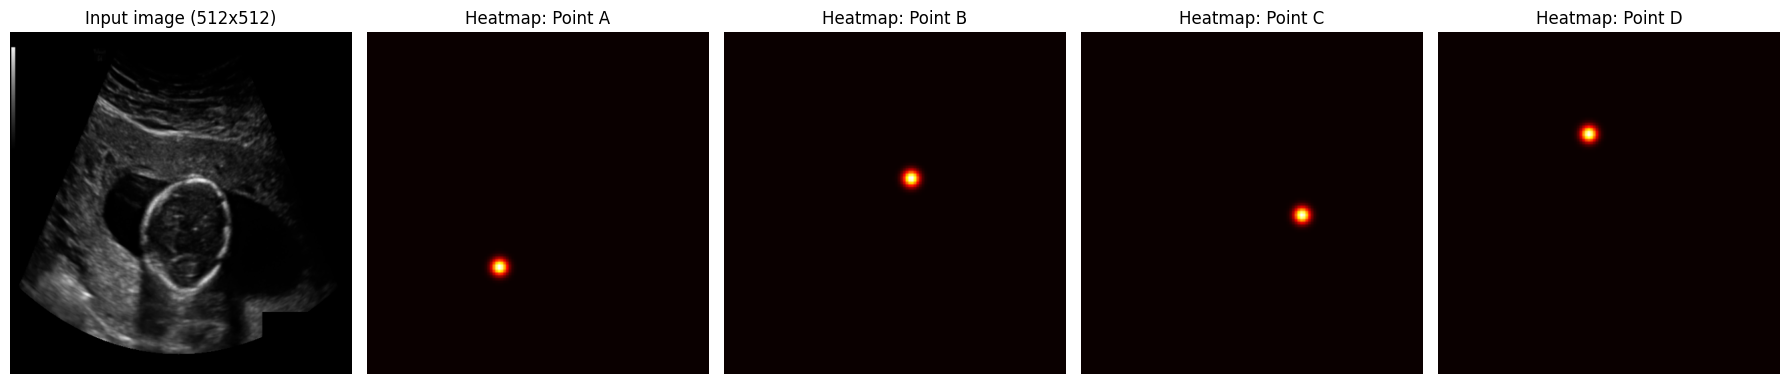

In [15]:
import zipfile
import os
import glob # For glob.glob

def generate_gaussian_heatmaps(keypoints, height, width, sigma):
    '''Create one Gaussian heatmap per keypoint.'''
    num_kp = len(keypoints)
    heatmaps = np.zeros((num_kp, height, width), dtype=np.float32)
    xx, yy = np.meshgrid(np.arange(width), np.arange(height))
    for i, (x, y) in enumerate(keypoints):
        if x < 0 or y < 0 or x >= width or y >= height:
            continue  # keypoint fell outside the image after resizing
        heatmaps[i] = np.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2))
    return heatmaps


# --- Fix: Ensure images are unzipped into IMG_DIR and path is correct ---
# IMG_DIR is currently './images' from cell jCFD77f83U3l
original_img_dir_base = IMG_DIR # Store original value, which is './images'

# Only attempt unzipping and path adjustment if the target image directory is not populated with PNGs
if not os.path.exists(original_img_dir_base) or not any(f.endswith('.png') for f in os.listdir(original_img_dir_base)):
    print(f"Directory {original_img_dir_base} not found or does not contain PNG images. Attempting to unzip images.zip...")
    zip_path = os.path.join(PROJECT_ROOT, "images.zip")
    if os.path.exists(zip_path):
        try:
            # Create the target directory if it doesn't exist
            os.makedirs(original_img_dir_base, exist_ok=True)

            # Extract to the original IMG_DIR base (e.g., './images')
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(original_img_dir_base)
            print(f"Successfully unzipped {zip_path} to {original_img_dir_base}")

            # Now, find the actual directory containing the images (e.g., '000_HC.png')
            found_image_dir = None
            # Assuming raw_df is available from a previous cell and contains 'image_name'
            first_image_name_to_find = None
            if 'raw_df' in globals() and not raw_df.empty:
                first_image_name_to_find = raw_df.iloc[0]['image_name']

            for root, dirs, files in os.walk(original_img_dir_base):
                if first_image_name_to_find and first_image_name_to_find in files:
                    found_image_dir = root
                    break
                elif not first_image_name_to_find and any(f.endswith(('.png', '.jpg', '.jpeg')) for f in files):
                    # Fallback if raw_df is not available or empty, just find any dir with common image types
                    found_image_dir = root
                    break

            if found_image_dir:
                global IMG_DIR # Explicitly declare global to modify the variable from jCFD77f83U3l
                IMG_DIR = found_image_dir
                print(f"Adjusted IMG_DIR to: {IMG_DIR}")
            else:
                print(f"Warning: No images (PNG, JPG, JPEG) found after unzipping within {original_img_dir_base}. IMG_DIR remains {original_img_dir_base}. This might lead to errors.")

        except zipfile.BadZipFile:
            print(f"Error: {zip_path} is not a valid zip file.")
        except Exception as e:
            print(f"An error occurred during unzipping or path adjustment: {e}")
    else:
        print(f"Error: {zip_path} not found. Please ensure 'images.zip' is uploaded.")
# --- End Fix ---


# quick example on one training image
_example_ds = FetalLandmarkDataset(train_df, IMG_DIR, eval_transform)
_sample = _example_ds[0]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
img_show = _sample["image"].permute(1, 2, 0).numpy()
img_show = (img_show * 0.5) + 0.5  # undo normalization for display
axes[0].imshow(img_show)
axes[0].set_title("Input image (512x512)")
axes[0].axis("off")

for i, name in enumerate(LANDMARK_ORDER):
    axes[i + 1].imshow(_sample["heatmaps"][i], cmap="hot")
    axes[i + 1].set_title(f"Heatmap: Point {name}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
class SimpleHRNetLandmark(nn.Module):
    def __init__(self, num_landmarks=4, pretrained=True):
        super().__init__()
        try:
            self.backbone = timm.create_model("hrnet_w32", pretrained=pretrained, features_only=True)
        except Exception as e:
            print("Could not download pretrained weights, using random initialisation instead.")
            print("Reason:", e)
            self.backbone = timm.create_model("hrnet_w32", pretrained=False, features_only=True)

        # index 1 = stride-4 branch = highest resolution kept by HRNet after stage 1
        high_res_channels = self.backbone.feature_info.channels()[1]
        self.head = nn.Conv2d(high_res_channels, num_landmarks, kernel_size=1)

    def forward(self, x):
        features = self.backbone(x)
        high_res_feature = features[1]
        heatmaps = self.head(high_res_feature)
        return heatmaps


model = SimpleHRNetLandmark(num_landmarks=4, pretrained=True).to(DEVICE)
print("Model created.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  165MB            

model.safetensors: downloading bytes:           |  0.00B            

Model created.


In [17]:
try:
    from torchinfo import summary
    summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), device=str(DEVICE))
except Exception as e:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("torchinfo not available, printing basic summary instead.")
    print(model)
    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

torchinfo not available, printing basic summary instead.
SimpleHRNetLandmark(
  (backbone): HighResolutionNetFeatures(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act2): ReLU(inplace=True)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

In [18]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
BATCH_SIZE = 8
NUM_WORKERS = 0  # set to 0 for maximum compatibility (avoids multiprocessing issues on some platforms/notebook kernels)

train_dataset = FetalLandmarkDataset(train_df, IMG_DIR, train_transform)
val_dataset = FetalLandmarkDataset(val_df, IMG_DIR, eval_transform)
test_dataset = FetalLandmarkDataset(test_df, IMG_DIR, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  Test batches: {len(test_loader)}")

Train batches: 63  Val batches: 8  Test batches: 8


In [20]:
EPOCHS = 20
best_val_loss = float("inf")
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # ---- training ----
    model.train()
    running_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]"):
        images = batch["image"].to(DEVICE)
        targets = batch["heatmaps"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)          # forward pass
        loss = criterion(outputs, targets)  # loss calculation
        loss.backward()                  # backpropagation
        optimizer.step()                 # optimizer step

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss)

    # ---- validation ----
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(DEVICE)
            targets = batch["heatmaps"].to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            val_running_loss += loss.item() * images.size(0)

    val_loss = val_running_loss / len(val_dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_hrnet.pth")
        print(f"  -> saved new best model (val_loss={val_loss:.6f})")

print("Training complete. Best validation loss:", best_val_loss)

Epoch 1/20 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/20 - train_loss: 0.000732 - val_loss: 0.000759
  -> saved new best model (val_loss=0.000759)


Epoch 2/20 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/20 - train_loss: 0.000581 - val_loss: 0.000626
  -> saved new best model (val_loss=0.000626)


Epoch 3/20 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 18/20 - train_loss: 0.000163 - val_loss: 0.000583


Epoch 19/20 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 19/20 - train_loss: 0.000154 - val_loss: 0.000588


Epoch 20/20 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 20/20 - train_loss: 0.000143 - val_loss: 0.000609
Training complete. Best validation loss: 0.0005487464377731685


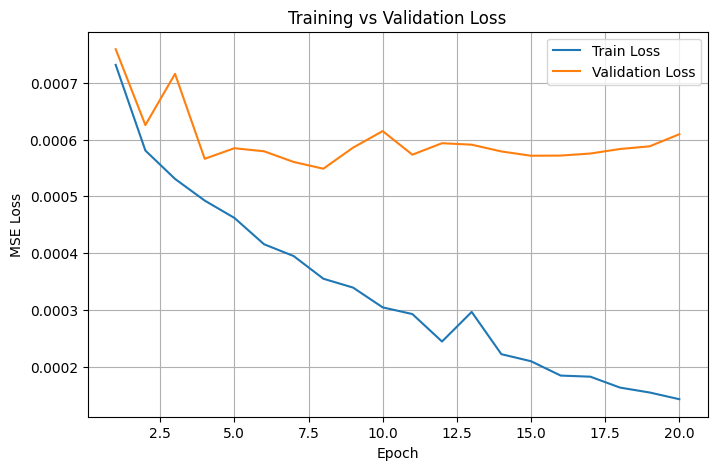

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
model.load_state_dict(torch.load("best_hrnet.pth", map_location=DEVICE))
model.eval()


def decode_heatmaps_to_coords(heatmaps):
    '''heatmaps: (N, K, H, W) tensor -> (N, K, 2) coordinates in heatmap space (x, y).'''
    N, K, H, W = heatmaps.shape
    flat = heatmaps.view(N, K, -1)
    idx = torch.argmax(flat, dim=2)
    ys = (idx // W).float()
    xs = (idx % W).float()
    return torch.stack([xs, ys], dim=2)


@torch.no_grad()
def predict_landmarks(image_tensor, orig_size):
    '''image_tensor: (3,H,W) preprocessed tensor. orig_size: (w,h) of the original image.
    Returns a dict with A, B, C, D coordinates in the ORIGINAL image pixel scale.'''
    image_batch = image_tensor.unsqueeze(0).to(DEVICE)
    heatmaps = model(image_batch)
    coords_hm = decode_heatmaps_to_coords(heatmaps)[0]  # (4,2) in heatmap space

    scale_x = orig_size[0] / HEATMAP_SIZE
    scale_y = orig_size[1] / HEATMAP_SIZE
    coords_orig = coords_hm.clone()
    coords_orig[:, 0] *= scale_x
    coords_orig[:, 1] *= scale_y

    return {name: coords_orig[i].cpu().numpy() for i, name in enumerate(LANDMARK_ORDER)}


# quick check on one test sample
_test_sample = test_dataset[0]
_pred = predict_landmarks(_test_sample["image"], _test_sample["orig_size"])
print("Predicted landmarks for", _test_sample["image_name"], ":", _pred)

Predicted landmarks for 199_HC.png : {'A': array([100., 270.], dtype=float32), 'B': array([362.5    ,  54.84375], dtype=float32), 'C': array([600.     , 265.78125], dtype=float32), 'D': array([400.     , 442.96875], dtype=float32)}


In [23]:
def euclidean_distance(p1, p2):
    return float(np.linalg.norm(np.array(p1) - np.array(p2)))


def compute_bpd_ofd(landmarks):
    '''landmarks: dict with keys A, B, C, D (numpy arrays / tuples).'''
    bpd = euclidean_distance(landmarks["A"], landmarks["C"])
    ofd = euclidean_distance(landmarks["B"], landmarks["D"])
    return bpd, ofd


_bpd, _ofd = compute_bpd_ofd(_pred)
print(f"Predicted BPD = {_bpd:.2f} px, Predicted OFD = {_ofd:.2f} px")

Predicted BPD = 500.02 px, Predicted OFD = 389.93 px


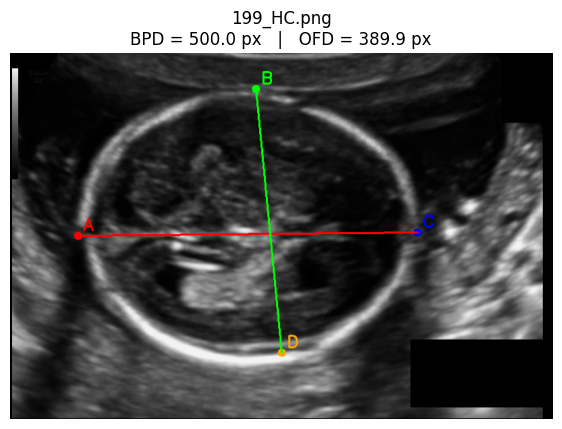

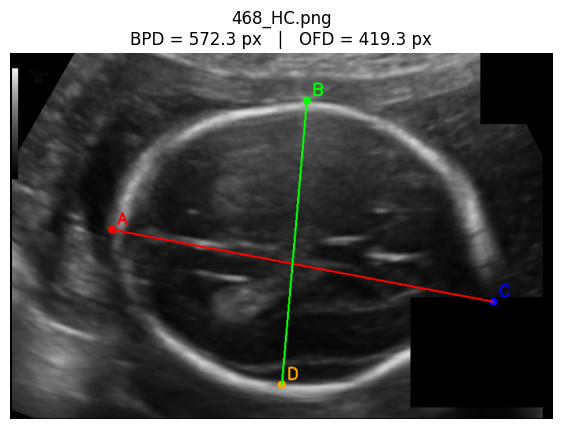

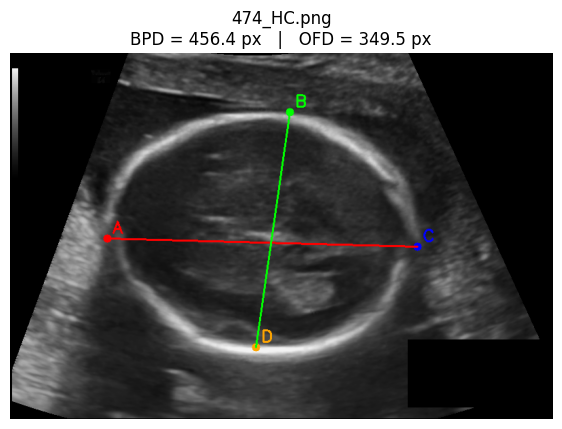

In [24]:
def visualize_prediction(image_name, img_dir=IMG_DIR):
    img_path = os.path.join(img_dir, image_name)
    image = cv2.imread(img_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = image.shape[:2]

    transformed = eval_transform(image=image, keypoints=[(0, 0)] * 4)  # dummy keypoints, only need the image
    image_t = transformed["image"]

    landmarks = predict_landmarks(image_t, torch.tensor([orig_w, orig_h], dtype=torch.float32))
    bpd, ofd = compute_bpd_ofd(landmarks)

    vis = image.copy()
    colors = {"A": (255, 0, 0), "B": (0, 255, 0), "C": (0, 0, 255), "D": (255, 165, 0)}
    for name, (x, y) in landmarks.items():
        cv2.circle(vis, (int(x), int(y)), 6, colors[name], -1)
        cv2.putText(vis, name, (int(x) + 8, int(y) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, colors[name], 2)

    a, c = landmarks["A"], landmarks["C"]
    b, d = landmarks["B"], landmarks["D"]
    cv2.line(vis, (int(a[0]), int(a[1])), (int(c[0]), int(c[1])), (255, 0, 0), 2)  # BPD line
    cv2.line(vis, (int(b[0]), int(b[1])), (int(d[0]), int(d[1])), (0, 255, 0), 2)  # OFD line

    plt.figure(figsize=(7, 5))
    plt.imshow(vis)
    plt.title(f"{image_name}\nBPD = {bpd:.1f} px   |   OFD = {ofd:.1f} px")
    plt.axis("off")
    plt.show()

    return landmarks, bpd, ofd


# visualize a few test images
for _name in test_df["image_name"].head(3):
    visualize_prediction(_name)

In [25]:
euclidean_errors = []
bpd_errors = []
ofd_errors = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluating"):
    img_path = os.path.join(IMG_DIR, row["image_name"])
    image = cv2.imread(img_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = image.shape[:2]

    transformed = eval_transform(image=image, keypoints=[(0, 0)] * 4)
    image_t = transformed["image"]

    pred = predict_landmarks(image_t, torch.tensor([orig_w, orig_h], dtype=torch.float32))
    gt = {
        "A": (row["Ax"], row["Ay"]),
        "B": (row["Bx"], row["By"]),
        "C": (row["Cx"], row["Cy"]),
        "D": (row["Dx"], row["Dy"]),
    }

    per_point_errors = [euclidean_distance(pred[name], gt[name]) for name in LANDMARK_ORDER]
    euclidean_errors.append(np.mean(per_point_errors))

    pred_bpd, pred_ofd = compute_bpd_ofd(pred)
    gt_bpd = euclidean_distance(gt["A"], gt["C"])
    gt_ofd = euclidean_distance(gt["B"], gt["D"])

    bpd_errors.append(abs(pred_bpd - gt_bpd))
    ofd_errors.append(abs(pred_ofd - gt_ofd))

print(f"Mean Euclidean Error : {np.mean(euclidean_errors):.2f} px")
print(f"Average BPD Error    : {np.mean(bpd_errors):.2f} px")
print(f"Average OFD Error    : {np.mean(ofd_errors):.2f} px")

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

Mean Euclidean Error : 56.07 px
Average BPD Error    : 27.78 px
Average OFD Error    : 41.94 px


In [26]:
records = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Saving predictions"):
    img_path = os.path.join(IMG_DIR, row["image_name"])
    image = cv2.imread(img_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = image.shape[:2]

    transformed = eval_transform(image=image, keypoints=[(0, 0)] * 4)
    image_t = transformed["image"]

    pred = predict_landmarks(image_t, torch.tensor([orig_w, orig_h], dtype=torch.float32))
    bpd, ofd = compute_bpd_ofd(pred)

    records.append({
        "Image Name": row["image_name"],
        "Ax": pred["A"][0], "Ay": pred["A"][1],
        "Bx": pred["B"][0], "By": pred["B"][1],
        "Cx": pred["C"][0], "Cy": pred["C"][1],
        "Dx": pred["D"][0], "Dy": pred["D"][1],
        "BPD": bpd,
        "OFD": ofd,
    })

predictions_df = pd.DataFrame(records)
predictions_df.to_csv("predictions.csv", index=False)
predictions_df.head()

Saving predictions:   0%|          | 0/63 [00:00<?, ?it/s]

,Image Name,Ax,Ay,Bx,By,Cx,Cy,Dx,Dy,BPD,OFD
0,199_HC.png,100.000000,270.000000,362.500000,54.84375,600.000000,265.781250,400.000000,442.96875,500.017792,389.932373
1,468_HC.png,150.000000,261.562500,437.500000,71.71875,712.500000,367.031250,400.000000,489.37500,572.302307,419.336395
2,474_HC.png,143.750000,274.218750,412.500000,88.59375,600.000000,286.875000,362.500000,434.53125,456.425507,349.532196
3,283_HC.png,112.500000,329.062500,406.250000,71.71875,637.500000,303.750000,381.250000,510.46875,525.609863,439.461670
4,309_HC.png,118.304688,228.234375,460.765625,50.71875,666.242188,257.820312,417.179688,439.56250,548.735657,391.278931
